# Convolutional Neural Networks for Image Classification

In [1]:
import pandas as pd
import numpy as np
from tensorflow.keras.datasets import mnist
import matplotlib.pyplot as plt

In [2]:
(x_train, y_train), (x_test, y_test) = mnist.load_data()
assert x_train.shape == (60000, 28, 28)
assert x_test.shape == (10000, 28, 28)
assert y_train.shape == (60000,)
assert y_test.shape == (10000,)

## Visualizing the Image Data

In [3]:
x_train.shape

(60000, 28, 28)

In [4]:
single_img = x_train[2]
single_img

array([[  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,  67, 232,  39,   0,   0,   0,
          0,   0],
       [  

In [5]:
single_img.shape

(28, 28)

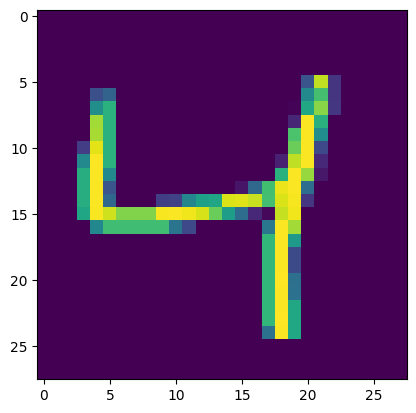

In [6]:
plt.imshow(single_img)

In [7]:
y_train[2]

4

# PreProcessing Data

We first need to make sure the labels will be understandable by our CNN.

In [8]:
y_train, y_test

(array([5, 0, 4, ..., 5, 6, 8], dtype=uint8),
 array([7, 2, 1, ..., 4, 5, 6], dtype=uint8))

Hmmm, looks like our labels are literally categories of numbers. We need to translate this to be "one hot encoded" so our CNN can understand, otherwise it will think this is some sort of regression problem on a continuous axis. Luckily , Keras has an easy to use function for this:

In [9]:
from tensorflow.keras.utils import to_categorical

In [10]:
y_train.shape, y_test.shape

((60000,), (10000,))

In [11]:
y_cat_train = to_categorical(y_train)
y_cat_train.shape

(60000, 10)

In [12]:
y_cat_train[2]

array([0., 0., 0., 0., 1., 0., 0., 0., 0., 0.])

In [13]:
y_cat_test = to_categorical(y_test,10)
y_cat_test

array([[0., 0., 0., ..., 1., 0., 0.],
       [0., 0., 1., ..., 0., 0., 0.],
       [0., 1., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]])

## Processing X Data
We should normalize the X data

In [14]:
single_img.max(), single_img.min()

(255, 0)

In [15]:
x_train = x_train/255
x_test = x_test/255
x_train[0], x_test[0] # normalizing value within 0-1, since, there are 255 combo, so

(array([[0.        , 0.        , 0.        , 0.        , 0.        ,
         0.        , 0.        , 0.        , 0.        , 0.        ,
         0.        , 0.        , 0.        , 0.        , 0.        ,
         0.        , 0.        , 0.        , 0.        , 0.        ,
         0.        , 0.        , 0.        , 0.        , 0.        ,
         0.        , 0.        , 0.        ],
        [0.        , 0.        , 0.        , 0.        , 0.        ,
         0.        , 0.        , 0.        , 0.        , 0.        ,
         0.        , 0.        , 0.        , 0.        , 0.        ,
         0.        , 0.        , 0.        , 0.        , 0.        ,
         0.        , 0.        , 0.        , 0.        , 0.        ,
         0.        , 0.        , 0.        ],
        [0.        , 0.        , 0.        , 0.        , 0.        ,
         0.        , 0.        , 0.        , 0.        , 0.        ,
         0.        , 0.        , 0.        , 0.        , 0.        ,
         0.

In [16]:
single_img = x_train[2]
single_img.max()

1.0

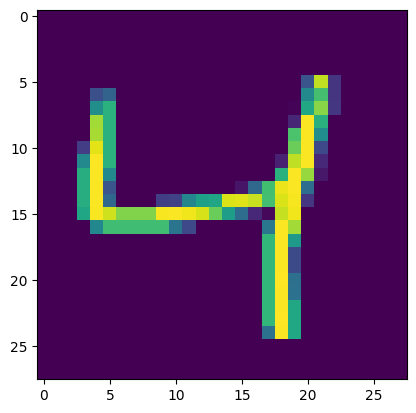

In [17]:
plt.imshow(single_img)

## Reshaping the Data

Right now our data is 60,000 images stored in 28 by 28 pixel array formation. 

This is correct for a CNN, but we need to add one more dimension to show we're dealing with 1 RGB channel (since technically the images are in black and white, only showing values from 0-255 on a single channel), an color image would have 3 dimensions.

In [18]:
x_train.shape, x_test.shape

((60000, 28, 28), (10000, 28, 28))

Reshape to include channel dimension (in this case, 1 channel)

In [19]:
x_train = x_train.reshape(-1, 28, 28, 1)
x_test = x_test.reshape(-1, 28, 28, 1)
x_train.shape, x_test.shape

((60000, 28, 28, 1), (10000, 28, 28, 1))

## Training the Model

In [20]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Conv2D, MaxPool2D, Flatten, Input

In [21]:
model = Sequential()

# # CONVOLUTIONAL LAYER
# model.add(Conv2D(filters=32, kernel_size=(4,4), 
#                  input_shape=(28,28,1), activation='relu'))

# LATEST WAY to ADD CONVOLUTIONAL LAYER
model.add(Input(shape=(28, 28, 1)))

model.add(Conv2D(filters=32, kernel_size=(4,4), activation='relu'))

# POOLING LAYER
model.add(MaxPool2D(pool_size=(2, 2),))

# FLATTEN IMAGES FROM 28 by 28 to 764 BEFORE FINAL LAYER
model.add(Flatten())

# 128 NEURONS IN DENSE HIDDEN LAYER (YOU CAN CHANGE THIS NUMBER OF NEURONS)
model.add(Dense(units=128, activation='relu'))

# LAST LAYER IS THE CLASSIFIER, THUS 10 POSSIBLE CLASSES
model.add(Dense(units=10, activation='softmax'))

# https://keras.io/metrics/
model.compile(optimizer='adam', loss='categorical_crossentropy', 
             metrics=['accuracy']) # we can add in additional metrics https://keras.io/metrics/

In [22]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 25, 25, 32)     │           544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 12, 12, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4608)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       589,952 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 591,786 (2.26 MB)

 Trainable params: 591,786 (2.26 MB)

 Non-trainable params: 0 (0.00 B)

In [23]:
from tensorflow.keras.callbacks import EarlyStopping

In [24]:
early_stop = EarlyStopping(monitor='val_loss', patience=2)
early_stop

In [25]:
# Train the model

model.fit(x=x_train, y=y_cat_train, epochs=10, validation_data=(x_test, y_cat_test), callbacks=[early_stop])

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.9138 - loss: 0.2804 - val_accuracy: 0.9849 - val_loss: 0.0477
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.9854 - loss: 0.0462 - val_accuracy: 0.9881 - val_loss: 0.0361
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.9922 - loss: 0.0260 - val_accuracy: 0.9861 - val_loss: 0.0418
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.9950 - loss: 0.0164 - val_accuracy: 0.9895 - val_loss: 0.0346
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.9965 - loss: 0.0118 - val_accuracy: 0.9882 - val_loss: 0.0382
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.9977 - loss: 0.0087 - val_accuracy: 0.9884 - val_loss: 0.0446


In [26]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 25, 25, 32)     │           544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 12, 12, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4608)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       589,952 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,775,360 (6.77 MB)

 Trainable params: 591,786 (2.26 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 1,183,574 (4.51 MB)

## Evaluate the Model

In [27]:
model.metrics_names

['loss', 'compile_metrics']

In [28]:
losses = pd.DataFrame(model.history.history)

In [29]:
losses.head()

,accuracy,loss,val_accuracy,val_loss
0,0.958900,0.133799,0.9849,0.047737
1,0.985967,0.044831,0.9881,0.036132
2,0.991283,0.028343,0.9861,0.041820
3,0.993967,0.018768,0.9895,0.034560
4,0.995700,0.012950,0.9882,0.038245


<Axes: >

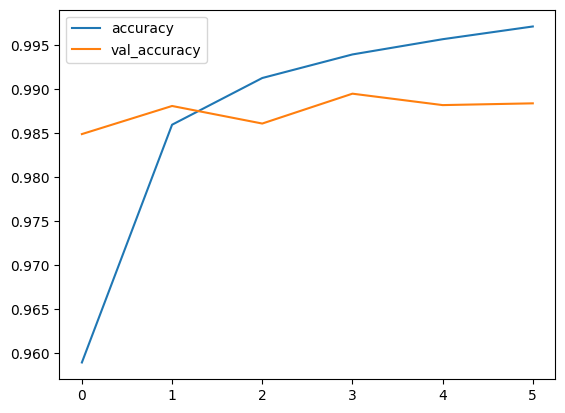

In [30]:
losses[['accuracy', 'val_accuracy']].plot()

<Axes: >

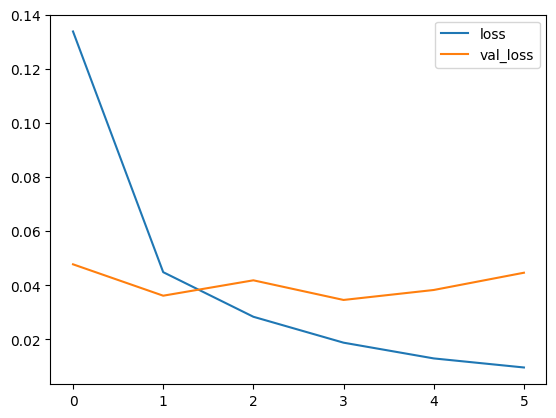

In [31]:
losses[['loss','val_loss']].plot()

In [32]:
print(model.metrics_names)
print(model.evaluate(x_test,y_cat_test,verbose=0))

['loss', 'compile_metrics']
[0.04462467506527901, 0.9883999824523926]


In [33]:
from sklearn.metrics import confusion_matrix, classification_report

In [34]:
# y_pred = model.predict_class(x_test)

AttributeError: 'Sequential' object has no attribute 'predict_class'

> #### Latest Changes

In [35]:
y_pred_probability = model.predict(x_test)
y_pred = np.argmax(y_pred_probability, axis=1)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


In [36]:
y_cat_test.shape, y_test.shape, y_pred.shape

((10000, 10), (10000,), (10000,))

In [37]:
y_cat_test[2]

array([0., 1., 0., 0., 0., 0., 0., 0., 0., 0.])

In [38]:
y_pred[2]

1